# StockBot: Vanilla LSTM for Stock Price Forecasting
Implements the stacked LSTM from *StockBot 2.0* (Mohanty, 2026).  
Compares **autoregressive** forecasting (model feeds its own predictions back) vs **teacher forcing** (ground truth in lookback at each step), then runs the StockBot buy/sell strategy.

In [1]:
%pip install -q yfinance torch numpy scikit-learn matplotlib pandas

## 0. Dataset Setup
Downloads the CSV from GitHub if not available locally (e.g. on Colab).

In [2]:
import os, urllib.request

CSV_NAME   = 'aapl_daily_sentiment_2021_2025.csv'
RAW_URL    = ('https://raw.githubusercontent.com/franciscomartinez45/'
              'Stock-Forecasting-LSTM/main/data/processed/' + CSV_NAME)
LOCAL_PATHS = [f'../data/processed/{CSV_NAME}', CSV_NAME]

if not any(os.path.exists(p) for p in LOCAL_PATHS):
    print('Downloading dataset from GitHub...')
    urllib.request.urlretrieve(RAW_URL, CSV_NAME)
    print('Done.')
else:
    print('Dataset found locally.')

Done.


## 1. Imports & Config

In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

# ── Hyperparameters (Table 1 from paper) ──────────────────────────────────
TICKER       = 'AAPL'           # swap to any yfinance-supported ticker
START_DATE   = '2021-05-01'
END_DATE     = '2025-12-31'
PAST_HISTORY = 60               # days of history per input window
HIDDEN_DIM   = 64
NUM_LAYERS   = 2
DROPOUT      = 0.1
BATCH_SIZE   = 64
LR           = 1e-3
EPOCHS       = 100              # paper uses 500; 100 suffices with early stopping
PATIENCE     = 15
TRAIN_RATIO  = 0.8

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Data
Adjusted close prices, z-score normalised using **training-set statistics only** to prevent leakage.

In [4]:
LOCAL_CSV = next(
    (p for p in ['../data/processed/aapl_daily_sentiment_2021_2025.csv',
                 'aapl_daily_sentiment_2021_2025.csv'] if os.path.exists(p)),
    None
)

def load_prices():
    if LOCAL_CSV and TICKER == 'AAPL':
        import pandas as pd
        df = pd.read_csv(LOCAL_CSV, parse_dates=['date'])
        return df['close'].values.astype(np.float32), df['date'].tolist()
    import yfinance as yf
    df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
    return df['Close'].values.flatten().astype(np.float32), df.index.tolist()

prices_raw, dates = load_prices()
n          = len(prices_raw)
train_size = int(n * TRAIN_RATIO)

scaler    = StandardScaler()
prices_sc = np.concatenate([
    scaler.fit_transform(prices_raw[:train_size].reshape(-1, 1)).flatten(),
    scaler.transform(prices_raw[train_size:].reshape(-1, 1)).flatten(),
])

print(f'Total: {n} days | Train: {train_size} | Test: {n - train_size}')

Total: 1160 days | Train: 928 | Test: 232


In [5]:
class StockDataset(Dataset):
    def __init__(self, prices):
        self.x = torch.tensor(prices, dtype=torch.float32).unsqueeze(-1)  # (T, 1)

    def __len__(self):
        return len(self.x) - PAST_HISTORY

    def __getitem__(self, idx):
        return self.x[idx : idx + PAST_HISTORY], self.x[idx + PAST_HISTORY, 0]

val_cut  = int(train_size * 0.9)
train_ds = StockDataset(prices_sc[:val_cut])
val_ds   = StockDataset(prices_sc[val_cut - PAST_HISTORY : train_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')

Train: 775 samples | Val: 93 samples


## 3. Model
Stacked LSTM (Equations 1–6 from paper). The final hidden state is projected to a scalar price prediction.

In [6]:
class StackedLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = 1,
            hidden_size = HIDDEN_DIM,
            num_layers  = NUM_LAYERS,
            batch_first = True,
            dropout     = DROPOUT if NUM_LAYERS > 1 else 0.0,
        )
        self.fc = nn.Linear(HIDDEN_DIM, 1)

    def forward(self, x):          # x: (batch, seq, 1)
        out, _ = self.lstm(x)      # (batch, seq, hidden)
        return self.fc(out[:, -1, :]).squeeze(-1)  # (batch,)

## 4. Training
Adam + MSE loss with early stopping on validation loss.

Epoch  10 | Train 0.0251 | Val 0.0889
Epoch  20 | Train 0.0197 | Val 0.0481
Epoch  30 | Train 0.0163 | Val 0.0540
Epoch  40 | Train 0.0134 | Val 0.0420
Early stop at epoch 44


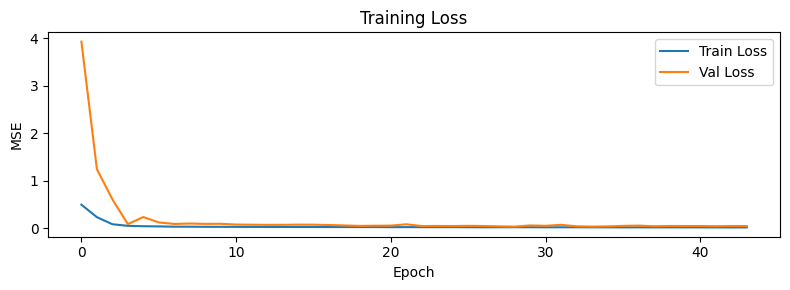

In [7]:
model     = StackedLSTM().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

best_val, patience_count = float('inf'), 0
tr_losses, vl_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        tr += loss.item()

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            vl += criterion(model(x.to(DEVICE)), y.to(DEVICE)).item()

    tr_losses.append(tr / len(train_loader))
    vl_losses.append(vl / max(len(val_loader), 1))

    if vl_losses[-1] < best_val:
        best_val, patience_count = vl_losses[-1], 0
        torch.save(model.state_dict(), 'best_lstm.pt')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stop at epoch {epoch}')
            break

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train {tr_losses[-1]:.4f} | Val {vl_losses[-1]:.4f}')

model.load_state_dict(torch.load('best_lstm.pt', map_location=DEVICE, weights_only=True))

plt.figure(figsize=(8, 3))
plt.plot(tr_losses, label='Train Loss')
plt.plot(vl_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()
plt.title('Training Loss'); plt.tight_layout(); plt.show()

## 5. One-Day-Ahead Forecasting
**Autoregressive**: model's own prediction is appended to the input window each step.  
**Teacher forcing**: ground-truth prices fill the lookback window at every step.

In [8]:
@torch.no_grad()
def autoregressive_forecast(init_window, n_steps):
    model.eval()
    window = list(init_window)
    preds  = []
    for _ in range(n_steps):
        x = torch.tensor(window[-PAST_HISTORY:], dtype=torch.float32).view(1, PAST_HISTORY, 1).to(DEVICE)
        p = model(x).item()
        preds.append(p)
        window.append(p)
    return np.array(preds)

@torch.no_grad()
def teacher_forcing_forecast(n_steps):
    model.eval()
    preds = []
    for i in range(n_steps):
        start = train_size - PAST_HISTORY + i
        x = torch.tensor(prices_sc[start : start + PAST_HISTORY],
                         dtype=torch.float32).view(1, PAST_HISTORY, 1).to(DEVICE)
        preds.append(model(x).item())
    return np.array(preds)

Autoregressive RMSE : 0.9061
Teacher Forcing RMSE: 0.3486


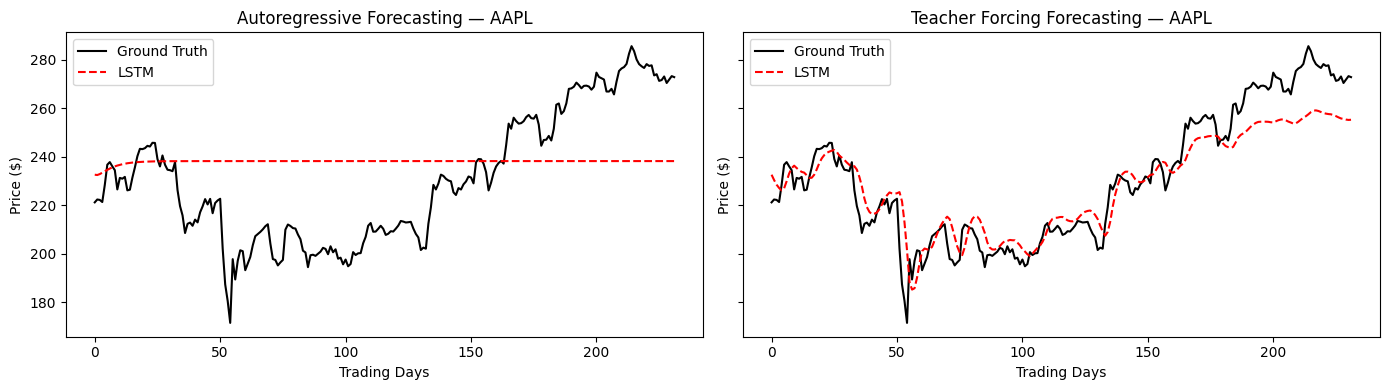

In [9]:
n_test      = n - train_size
init_window = prices_sc[train_size - PAST_HISTORY : train_size]

ar_sc = autoregressive_forecast(init_window, n_test)
tf_sc = teacher_forcing_forecast(n_test)
gt_sc = prices_sc[train_size:]

print(f'Autoregressive RMSE : {np.sqrt(np.mean((ar_sc - gt_sc)**2)):.4f}')
print(f'Teacher Forcing RMSE: {np.sqrt(np.mean((tf_sc - gt_sc)**2)):.4f}')

inv = lambda x: scaler.inverse_transform(x.reshape(-1, 1)).flatten()
actual, ar_preds, tf_preds = inv(gt_sc), inv(ar_sc), inv(tf_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, preds, title in zip(axes, [ar_preds, tf_preds], ['Autoregressive', 'Teacher Forcing']):
    ax.plot(actual, color='black', label='Ground Truth', linewidth=1.5)
    ax.plot(preds,  color='red',   label='LSTM', linestyle='--')
    ax.set_title(f'{title} Forecasting — {TICKER}')
    ax.set_xlabel('Trading Days'); ax.set_ylabel('Price ($)'); ax.legend()
plt.tight_layout(); plt.show()

## 6. StockBot Trading Strategy
Uses Algorithm 1 from the paper: δᵢ = sign(cᵢ₊₁ − cᵢ), Δᵢ = δᵢ₊₁ − δᵢ.  
Buy when Δᵢ = −2 (local minimum), sell when Δᵢ = 2 (local maximum).

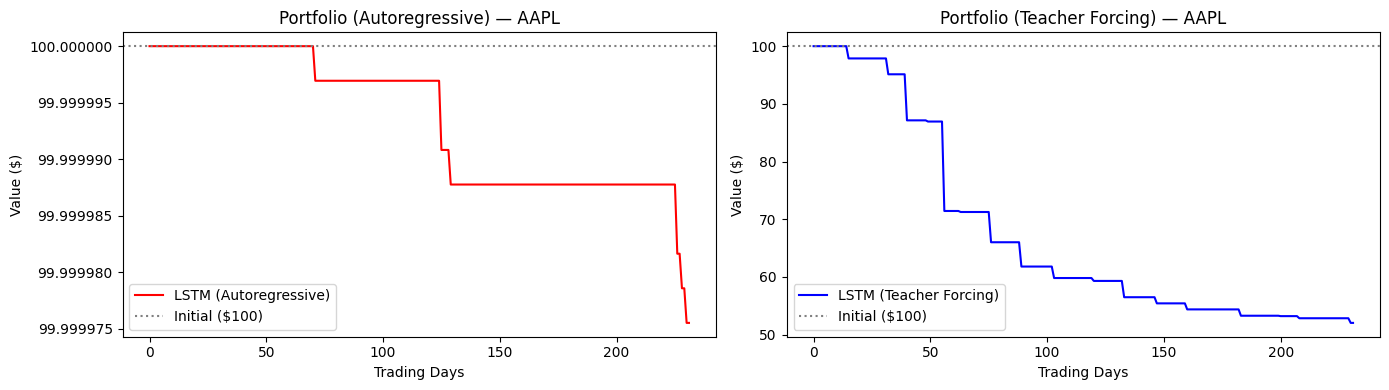

AR  final value: $100.00
TF  final value: $52.03


In [11]:
def stockbot_portfolio(prices, capital=100.0):
    delta = np.sign(np.diff(prices)).astype(int)  # direction of change
    Delta = np.diff(delta)                         # curvature
    held, buy_price, cur = False, 0.0, capital
    portfolio = [cur]
    for i, d in enumerate(Delta):                  # len = N-2
        signal_price = prices[i + 1]
        if d == -2 and not held:                   # local min → buy
            held, buy_price = True, signal_price
        elif d == 2 and held:                      # local max → sell
            held = False
            cur *= signal_price / buy_price
        portfolio.append(cur)
    portfolio.append(cur)                          # final day
    return np.array(portfolio)

ar_port = stockbot_portfolio(ar_preds)
tf_port = stockbot_portfolio(tf_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, port, label, color in zip(
    axes, [ar_port, tf_port],
    ['Autoregressive', 'Teacher Forcing'], ['red', 'blue']
):
    ax.plot(port, color=color, label=f'LSTM ({label})')
    ax.axhline(100, color='gray', linestyle=':', label='Initial ($100)')
    ax.ticklabel_format(useOffset=False, style='plain')
    ax.set_title(f'Portfolio ({label}) — {TICKER}')
    ax.set_xlabel('Trading Days'); ax.set_ylabel('Value ($)'); ax.legend()
plt.tight_layout(); plt.show()
print(f'AR  final value: ${ar_port[-1]:.2f}')
print(f'TF  final value: ${tf_port[-1]:.2f}')